# MemeCollector Graph 시각화

LangGraph의 `compile()` 후 그래프 구조를 시각화합니다.

In [16]:
import sys
sys.path.insert(0, '..')

In [17]:
from meme_collector.deep_research.graph import compile_graph

graph = compile_graph()

## 실제 워크플로우 (Command 동적 라우팅 포함)

LangGraph의 `Command` 패턴은 런타임 동적 라우팅이라 `get_graph()`에 안 보입니다.  
아래는 `supervisor.py`의 실제 라우팅 로직을 반영한 다이어그램입니다.

In [18]:
from IPython.display import display, HTML
import base64

ACTUAL_FLOW = """
flowchart LR
    subgraph START[ ]
        S(("🚀 START"))
    end
    
    subgraph SUPERVISOR[Supervisor]
        SV{{"supervisor"}}
    end
    
    subgraph RESEARCH[1. Research 병렬]
        T["📝 text"]
        M["🎬 media"]
        U["💬 usage"]
    end
    
    subgraph PROCESS[2. Process]
        A["🔍 analyzer"]
        V["✅ verifier"]
    end
    
    subgraph FINISH[ ]
        F["📦 finalize"]
        E(("🏁 END"))
    end
    
    S --> SV
    SV --> T & M & U
    T & M & U --> SV
    SV -->|done| A
    A --> SV
    SV -->|analyzed| V
    V --> SV
    SV -->|PASS| F
    SV -->|FAIL| E
    F --> E
    
    V -.->|RETRY| T & M & U & A

    style SV fill:#ffd700,stroke:#333,stroke-width:3px
    style T fill:#c8e6c9,stroke:#2e7d32
    style M fill:#c8e6c9,stroke:#2e7d32
    style U fill:#c8e6c9,stroke:#2e7d32
    style A fill:#bbdefb,stroke:#1565c0
    style V fill:#bbdefb,stroke:#1565c0
    style F fill:#e1bee7,stroke:#7b1fa2
"""

encoded = base64.urlsafe_b64encode(ACTUAL_FLOW.encode()).decode()
svg_url = f"https://mermaid.ink/svg/{encoded}"

display(HTML(f'''
<div style="background: #fafafa; padding: 30px; border-radius: 12px; border: 1px solid #ddd;">
    <img src="{svg_url}" style="width: 100%;" />
</div>
<div style="margin-top: 16px; font-size: 14px; color: #666;">
    <b>범례:</b> 
    🟡 Supervisor (라우터) &nbsp;|&nbsp;
    🟢 Researchers (병렬) &nbsp;|&nbsp;
    🔵 Workers &nbsp;|&nbsp;
    🟣 Finalize &nbsp;|&nbsp;
    ⋯→ RETRY 경로
</div>
'''))

## PNG 이미지 (Mermaid 기반)

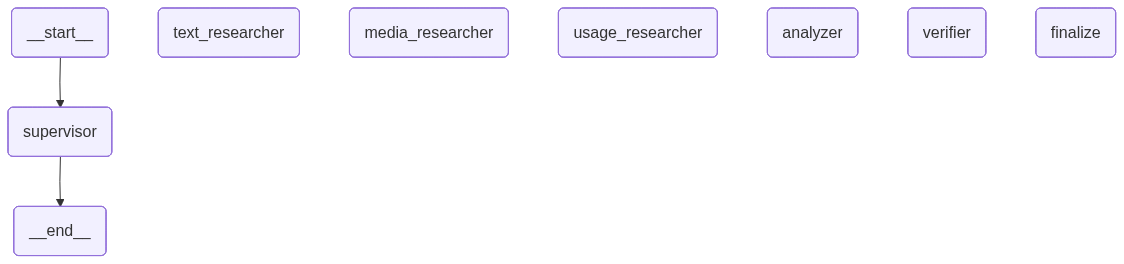

In [19]:
from IPython.display import Image, display

# Mermaid.ink API를 통한 PNG 렌더링
display(Image(graph.get_graph().draw_mermaid_png()))

## ASCII 다이어그램

In [20]:
# ASCII로 출력 (터미널 호환)
graph.get_graph().print_ascii()

ImportError: Install grandalf to draw graphs: `pip install grandalf`.

## 노드/엣지 정보

In [ ]:
g = graph.get_graph()

print("=== 노드 ===")
for node in g.nodes:
    print(f"  - {node}")

print("\n=== 엣지 ===")
for edge in g.edges:
    print(f"  {edge}")

=== 노드 ===
  - __start__
  - supervisor
  - text_researcher
  - media_researcher
  - usage_researcher
  - analyzer
  - verifier
  - finalize
  - __end__

=== 엣지 ===
  Edge(source='__start__', target='supervisor', data=None, conditional=False)
  Edge(source='supervisor', target='__end__', data=None, conditional=False)
